## Accessing NAIP data with the Planetary Computer STAC API

The [National Agriculture Imagery Program](https://www.fsa.usda.gov/programs-and-services/aerial-photography/imagery-programs/naip-imagery/) (NAIP) provides US-wide, high-resolution aerial imagery, with four spectral bands (R, G, B, IR).  NAIP is administered by the [Aerial Field Photography Office](https://www.fsa.usda.gov/programs-and-services/aerial-photography/) (AFPO) within the [US Department of Agriculture](https://www.usda.gov/) (USDA).  Data are captured at least once every three years for each state.  This dataset represents NAIP data from 2010-present, in [cloud-optimized GeoTIFF](https://www.cogeo.org/) format.

This notebook demonstrates the use of the Planetary Computer STAC API to query for NAIP imagery.

### Environment setup

This notebook works with or without an API key, but you will be given more permissive access to the data with an API key.
The [Planetary Computer Hub](https://planetarycomputer.microsoft.com/compute) is pre-configured to use your API key.

In [1]:
import pystac_client
import planetary_computer

# Set the environment variable PC_SDK_SUBSCRIPTION_KEY, or set it here.
# The Hub sets PC_SDK_SUBSCRIPTION_KEY automatically.
# pc.settings.set_subscription_key(<YOUR API Key>)

### Data access

The datasets hosted by the Planetary Computer are available from [Azure Blob Storage](https://docs.microsoft.com/en-us/azure/storage/blobs/). We'll use [pystac-client](https://pystac-client.readthedocs.io/) to search the Planetary Computer's [STAC API](https://planetarycomputer.microsoft.com/api/stac/v1/docs) for the subset of the data that we care about, and then we'll load the data directly from Azure Blob Storage. We'll specify a `modifier` so that we can access the data stored in the Planetary Computer's private Blob Storage Containers. See [Reading from the STAC API](https://planetarycomputer.microsoft.com/docs/quickstarts/reading-stac/) and [Using tokens for data access](https://planetarycomputer.microsoft.com/docs/concepts/sas/) for more.

In [2]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

### Choose our region and times of interest

This area is in South Jordan, Utah, which the Internet says is one of the fastest-growing cities in the US.  Let's see whether we can see some development in this area in the time spanned by our NAIP collection.

In [45]:
area_of_interest = {
    "type": "Polygon",
    "coordinates": [
        [
            [-111.9839859008789, 40.5389819819361],
            [-111.90502166748045, 40.5389819819361],
            [-111.90502166748045, 40.57015381856105],
            [-111.9839859008789, 40.57015381856105],
            [-111.9839859008789, 40.5389819819361],
        ]
    ],
}

In [70]:
type(area_of_interest)

dict

This collection includes data from 2010, so we'll search for one image near the beginning of that range and one from 2018.

In [63]:
import fiona
from shapely.geometry import shape

# Open the shapefile
with fiona.open("tiles_pc_test.shp") as shapefile:
    # Iterate over the records
    for record in shapefile:
        # Get the geometry from the record
        aoi = shape(record['geometry'])
        
        # Print the area of the geometry
        #print(geometry.area)

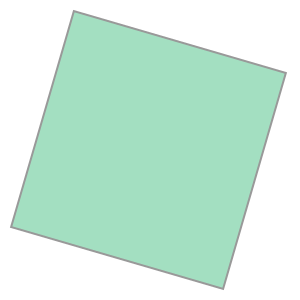

In [64]:
aoi

In [72]:
import geopandas

In [71]:
aoi=shapefile.to_file("file.geojson",driver='GeoJSON')

aoi=geopandas.read_file("file.geojson")

aoi

AttributeError: 'Collection' object has no attribute 'to_file'

In [39]:
for feat in fiona.open("tiles_pc_test.shp"):
     print (feat)

In [67]:
from shapely.geometry import shape

area_shape = aoi
target_area = area_shape.area


def area_of_overlap(item):
    overlap_area = shape(item.geometry).intersection(aoi).area
    return overlap_area / target_area


item_old = sorted(items_old, key=area_of_overlap, reverse=True)[0]
item_new = sorted(items_new, key=area_of_overlap, reverse=True)[0]

In [52]:
from shapely.geometry import shape

area_shape = geometry
target_area = area_shape.area


def area_of_overlap(item):
    overlap_area = shape(item.geometry).intersection(shape(area_of_interest)).area
    return overlap_area / target_area


item_old = sorted(items_old, key=area_of_overlap, reverse=True)[0]
item_new = sorted(items_new, key=area_of_overlap, reverse=True)[0]

In [68]:
type(aoi)

shapely.geometry.polygon.Polygon

In [69]:
range_old = "2010-01-01/2013-01-01"
range_new = "2018-01-01/2021-01-01"

In [54]:
search_old = catalog.search(
    collections=["naip"], intersects=area_of_interest, datetime=range_old
)

search_new = catalog.search(
    collections=["naip"], intersects=area_of_interest, datetime=range_new
)

items_old = search_old.item_collection()
items_new = search_new.item_collection()

print(f"{len(items_old)} Items found in the 'old' range")
print(f"{len(items_new)} Items found in the 'new' range")

4 Items found in the 'old' range
4 Items found in the 'new' range


As seen above, there are multiple items that intersect our area of interest for each year. The following code will choose the item that has the most overlap:

In [60]:
from shapely.geometry import shape

area_shape = geometry
target_area = area_shape.area


def area_of_overlap(item):
    overlap_area = shape(item.geometry).intersection(geometry).area
    return overlap_area / target_area


item_old = sorted(items_old, key=area_of_overlap, reverse=True)[0]
item_new = sorted(items_new, key=area_of_overlap, reverse=True)[0]

In [62]:
target_area

3997844.349886841

### Render images

Each Item has a `rendered_preview` which uses the Planetary Computer's Data API to dynamically create a preview image from the raw data.

In [61]:
from IPython.display import Image

Image(url=item_old.assets["rendered_preview"].href)

In [56]:
Image(url=item_new.assets["rendered_preview"].href)

To read the raw Cloud Optimized GeoTIFF, use a library like [rioxarray](https://corteva.github.io/rioxarray/html/rioxarray.html) or [rasterio](https://rasterio.readthedocs.io/) and the `image` asset.

In [9]:
import rioxarray

ds = rioxarray.open_rasterio(item_old.assets["image"].href).sel(band=[1, 2, 3])
ds

<xarray.DataArray (band: 3, y: 7630, x: 6000)> Size: 137MB
[137340000 values with dtype=uint8]
Coordinates:
  * band         (band) int64 24B 1 2 3
  * x            (x) float64 48kB 4.15e+05 4.15e+05 ... 4.209e+05 4.209e+05
  * y            (y) float64 61kB 4.491e+06 4.491e+06 ... 4.483e+06 4.483e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

In [10]:
import shapely.geometry
clipped = ds.rio.clip([shapely.geometry.shape(area_of_interest)], crs="WGS84").compute()
clipped

/srv/conda/envs/notebook/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:215: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


<xarray.DataArray (band: 3, y: 2989, x: 4279)> Size: 38MB
array([[[  0,   0,   0, ..., 193, 191, 185],
        [  0,   0,   0, ..., 181, 181, 178],
        [  0,   0,   0, ..., 163, 160, 170],
        ...,
        [  0,   0,   0, ...,  57,  61,  61],
        [  0,   0,   0, ...,  53,  54,  56],
        [  0,   0,   0, ...,  55,  55,  54]],

       [[  0,   0,   0, ..., 196, 196, 192],
        [  0,   0,   0, ..., 187, 186, 184],
        [  0,   0,   0, ..., 169, 160, 173],
        ...,
        [  0,   0,   0, ...,  85,  87,  87],
        [  0,   0,   0, ...,  80,  81,  84],
        [  0,   0,   0, ...,  82,  83,  81]],

       [[  0,   0,   0, ..., 185, 186, 184],
        [  0,   0,   0, ..., 181, 182, 183],
        [  0,   0,   0, ..., 179, 184, 189],
        ...,
        [  0,   0,   0, ...,  79,  74,  73],
        [  0,   0,   0, ...,  72,  73,  74],
        [  0,   0,   0, ...,  78,  74,  75]]], dtype=uint8)
Coordinates:
  * band         (band) int64 24B 1 2 3
  * x            (x) float64 34kB 4.167e+05 4.167e+05 ... 4.209e+05 4.209e+05
  * y            (y) float64 24kB 4.491e+06 4.491e+06 ... 4.488e+06 4.488e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

In [11]:
clipped.rio.to_raster("clipped_NAIP.tif")

In [12]:
from rasterio.enums import Resampling

In [18]:
scale_factor = 1/2
clipped.rio.width * scale_factor

2139.5

In [14]:
scale_factor = 1/2
new_width = clipped.rio.width * scale_factor
new_height = clipped.rio.height * scale_factor

ds_clip_res = clipped.rio.reproject(
    clipped.rio.crs,
    shape=(int(new_height), int(new_width)),
    resampling=Resampling
    .bilinear,
)

In [25]:
(int(new_height), int(new_width))
#clipped.rio.resolution()
#ds_clip_res.rio.resolution()

(1494, 2139)

In [24]:
ds_resampled.rio.width()

TypeError: 'int' object is not callable

In [15]:
ds.rio.to_raster("resample_NAIP.tif")